# imports

In [1]:
import os
import zipfile
import urllib.request
import random
import torchvision
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage.feature import local_binary_pattern
from skimage.filters.rank import entropy
from skimage.morphology import disk
import torchvision.transforms as transforms

In [ ]:
!git pull

# sync github

In [2]:
repo_name = "SIV-Texture-Anomaly-detection"
git_url = "https://github.com/Marco1743/SIV-Texture-Anomaly-detection.git"
if not os.path.exists(repo_name):
    !git clone {git_url}
%cd {repo_name}
!git pull

Cloning into 'SIV-Texture-Anomaly-detection'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 64 (delta 32), reused 43 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 21.21 KiB | 21.21 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/SIV-Texture-Anomaly-detection
Already up to date.


# import dataset

In [3]:
os.makedirs('data/train/good', exist_ok=True)
os.makedirs('data/test/anomaly', exist_ok=True)

print("Scaricamento Texture reali (DTD Dataset)...")
dtd_train = torchvision.datasets.DTD(root='./data', split='train', download=True)
dtd_test = torchvision.datasets.DTD(root='./data', split='test', download=True)

Scaricamento Texture reali (DTD Dataset)...


100%|██████████| 625M/625M [00:28<00:00, 22.2MB/s]


## creazione train e test

In [4]:
print("creazione training")
count = 0
for img, label in dtd_train:
    img_gray = img.convert('L')
    img_gray.save(f'data/train/good/tex_{count}.png')
    count += 1

print("Generazione anomalie...")
for i in range(50):
    img, _ = dtd_test[i]
    img_arr = np.array(img.convert('L'))
    h, w = img_arr.shape

    tipo_anomalia = random.choice([0, 1])

    if tipo_anomalia == 0:
        box_h = random.randint(10, 50)
        box_w = random.randint(10, 50)
        y = random.randint(0, h - box_h)
        x = random.randint(0, w - box_w)
        intensita = random.randint(0, 60)

        img_arr[y:y+box_h, x:x+box_w] = intensita

    else:
        spessore = random.randint(2, 6)
        lunghezza = random.randint(40, 100)

        if random.choice([True, False]):
            y = random.randint(0, h - spessore)
            x = random.randint(0, w - lunghezza)
            img_arr[y:y+spessore, x:x+lunghezza] = 255
        else:
            y = random.randint(0, h - lunghezza)
            x = random.randint(0, w - spessore)
            img_arr[y:y+lunghezza, x:x+spessore] = 255

    Image.fromarray(img_arr).save(f'data/test/anomaly/anom_{i}.png')

print(f"Dataset pronto e processato con augmentations.py! Totale: {count}")

creazione training
Generazione anomalie...
Dataset pronto e processato con augmentations.py! Totale: 1880


# PIPELINE 1

## Carichiamo l'immagine

In [5]:
img_path = 'data/test/anomaly/anom_0.png'
img = cv2.imread(img_path, 0)

## Estrazione LBP

In [6]:
radius = 3
n_points = 8 * radius
lbp_img = local_binary_pattern(img, n_points, radius, method='uniform')

## Entropia Locale sull'LBP

In [7]:
# Convertiamo l'LBP in un formato digeribile dal filtro di entropia (uint8 0-255)
lbp_uint8 = cv2.normalize(lbp_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
# Calcoliamo l'entropia (il disordine) in una finestra circolare (raggio 15 pixel)
# Il graffio romperà la regolarità delle strisce, creando un picco di entropia!
entropia_locale = entropy(lbp_uint8, disk(15))

## Segmentazione K-Means sulla mappa di Entropia

In [8]:
X = entropia_locale.reshape((-1, 1))
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)
anomaly_mask = kmeans.labels_.reshape(img.shape)
# Trucchetto: Assicuriamoci che l'anomalia sia sempre bianca (1) e lo sfondo nero (0)
# Poiché le anomalie sono piccole, il cluster "anomalo" avrà sempre meno pixel dello sfondo
if np.sum(anomaly_mask) > (anomaly_mask.size / 2):
    anomaly_mask = 1 - anomaly_mask

## Visualizzazione

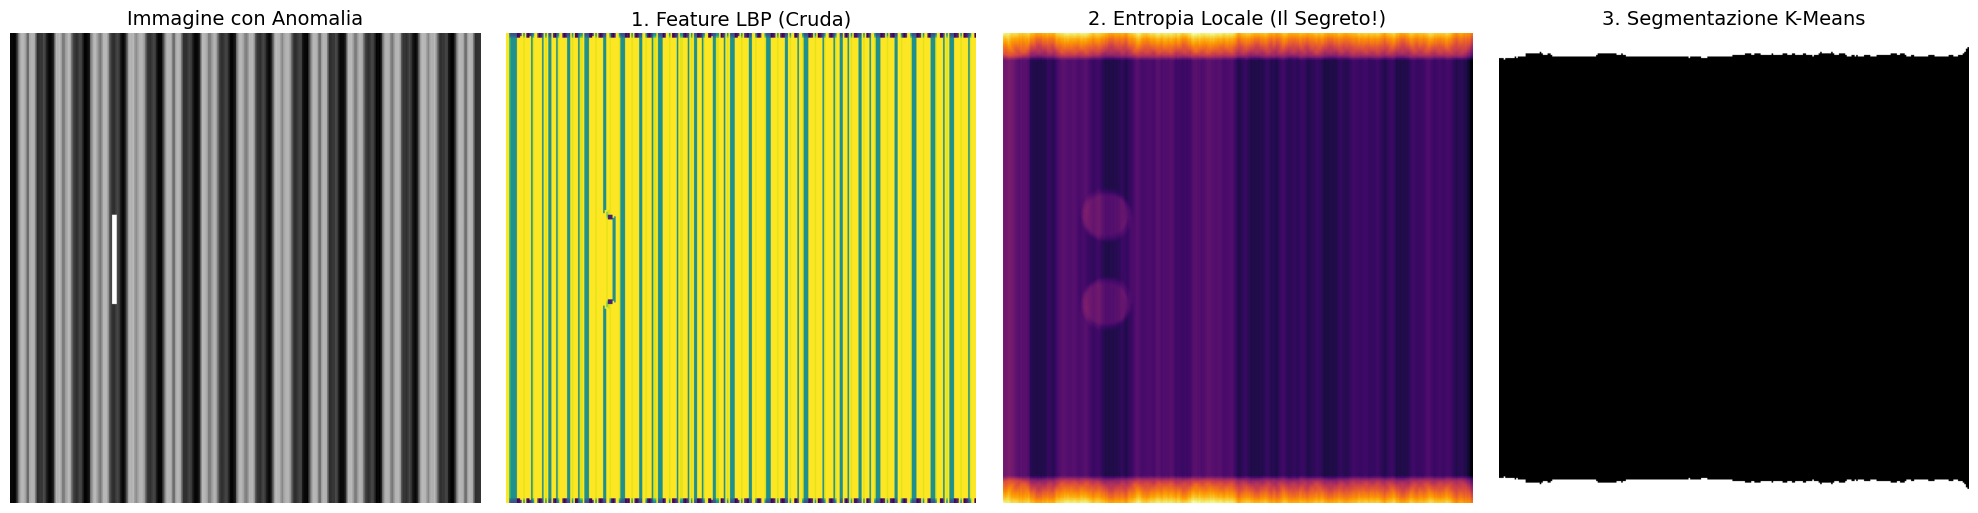

In [9]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.title("Immagine con Anomalia", fontsize=14)
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("1. Feature LBP (Cruda)", fontsize=14)
plt.imshow(lbp_img, cmap='viridis')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("2. Entropia Locale (Il Segreto!)", fontsize=14)
plt.imshow(entropia_locale, cmap='inferno')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("3. Segmentazione K-Means", fontsize=14)
plt.imshow(anomaly_mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

Inizializzazione del PyTorch Dataset per MoCo...


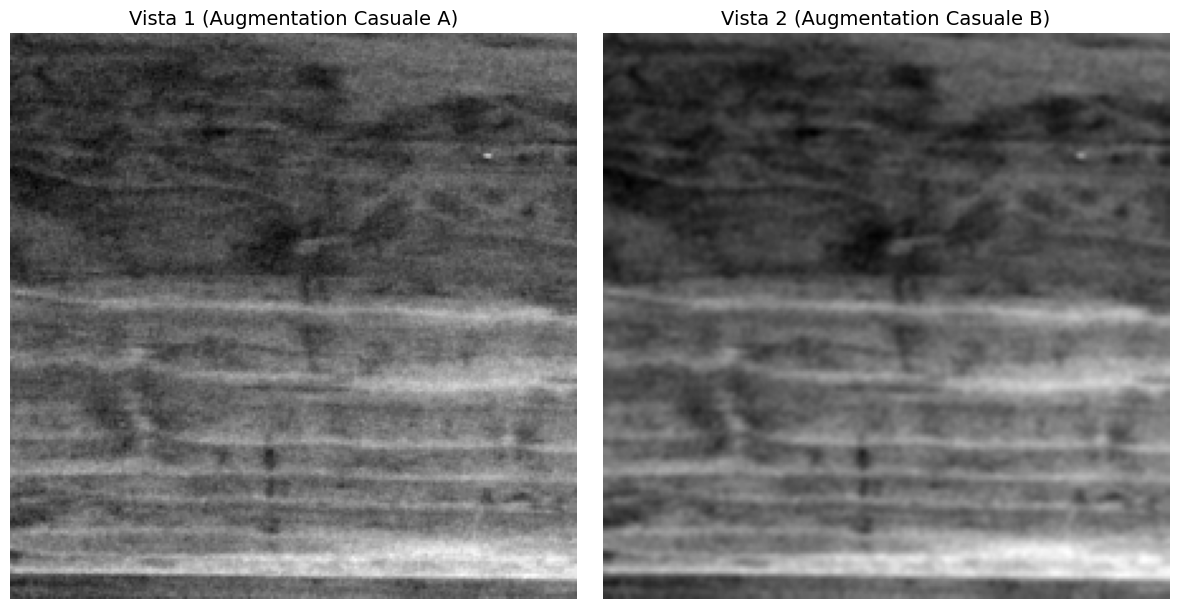

Shape del tensore 1: torch.Size([1, 224, 224])
Shape del tensore 2: torch.Size([1, 224, 224])


In [10]:
from dataset import MoCoTextureDataset
print("Inizializzazione del PyTorch Dataset per MoCo...")
train_dataset = MoCoTextureDataset(data_dir='data/train/good', is_train=True)
view_1, view_2 = train_dataset[5]

to_pil = transforms.ToPILImage()
img_1 = to_pil(view_1)
img_2 = to_pil(view_2)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Vista 1 (Augmentation Casuale A)", fontsize=14)
plt.imshow(img_1, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Vista 2 (Augmentation Casuale B)", fontsize=14)
plt.imshow(img_2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Shape del tensore 1: {view_1.shape}")
print(f"Shape del tensore 2: {view_2.shape}")

In [11]:
# Sincronizziamo GitHub per scaricare la tua versione corretta con il Resize(224, 224)
!git pull

import torch
from torch.utils.data import DataLoader
from dataset import MoCoTextureDataset
from model import MoCo

print("--- FASE 1: Setup dell'Hardware ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in uso: {device}")

print("\n--- FASE 2: Inizializzazione Dati ---")
train_dataset = MoCoTextureDataset(data_dir='data/train/good', is_train=True)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
print("DataLoader pronto.")

print("\n--- FASE 3: Caricamento Rete Neurale ---")
model = MoCo(dim=128, K=1024).to(device)
print("Architettura MoCo (ResNet18 + Momentum Queue) istanziata.")

print("\n--- FASE 4: Test del Forward Pass (Il Motore gira!) ---")
view_1, view_2 = next(iter(train_loader))

view_1 = view_1.to(device)
view_2 = view_2.to(device)

logits, labels = model(view_1, view_2)

print("\n✅ TEST SUPERATO: Nessun errore di dimensione!")
print(f"Input Shape: {view_1.shape}  --> [Batch Size, Canali, Altezza, Larghezza]")
print(f"Logits Shape: {logits.shape} --> [Batch Size, 1 (Risposta Giusta) + K (Risposte Sbagliate)]")
print(f"Labels Shape: {labels.shape}     --> [Batch Size]")

Already up to date.
--- FASE 1: Setup dell'Hardware ---
Device in uso: cuda

--- FASE 2: Inizializzazione Dati ---
DataLoader pronto.

--- FASE 3: Caricamento Rete Neurale ---
Architettura MoCo (ResNet18 + Momentum Queue) istanziata.

--- FASE 4: Test del Forward Pass (Il Motore gira!) ---

✅ TEST SUPERATO: Nessun errore di dimensione!
Input Shape: torch.Size([4, 1, 224, 224])  --> [Batch Size, Canali, Altezza, Larghezza]
Logits Shape: torch.Size([4, 1025]) --> [Batch Size, 1 (Risposta Giusta) + K (Risposte Sbagliate)]
Labels Shape: torch.Size([4])     --> [Batch Size]


--- FASE 1: Setup ---
Device in uso: cuda

Preparazione del DataLoader...

🚀 INIZIO ADDESTRAMENTO MOCO (15 Epoche) 🚀


Epoca [1/15]: 100%|██████████| 58/58 [06:39<00:00,  6.89s/it, loss=5.64]


-> Fine Epoca 1 | Loss Media: 5.4157



Epoca [2/15]: 100%|██████████| 58/58 [06:44<00:00,  6.97s/it, loss=5.38]


-> Fine Epoca 2 | Loss Media: 5.3996



...

-> Fine Epoca 13 | Loss Media: 4.7380



Epoca [14/15]: 100%|██████████| 58/58 [07:12<00:00,  7.45s/it, loss=4.91]


-> Fine Epoca 14 | Loss Media: 4.7332



Epoca [15/15]: 100%|██████████| 58/58 [06:59<00:00,  7.23s/it, loss=4.32]


-> Fine Epoca 15 | Loss Media: 4.6582


✅ ADDESTRAMENTO CONCLUSO!


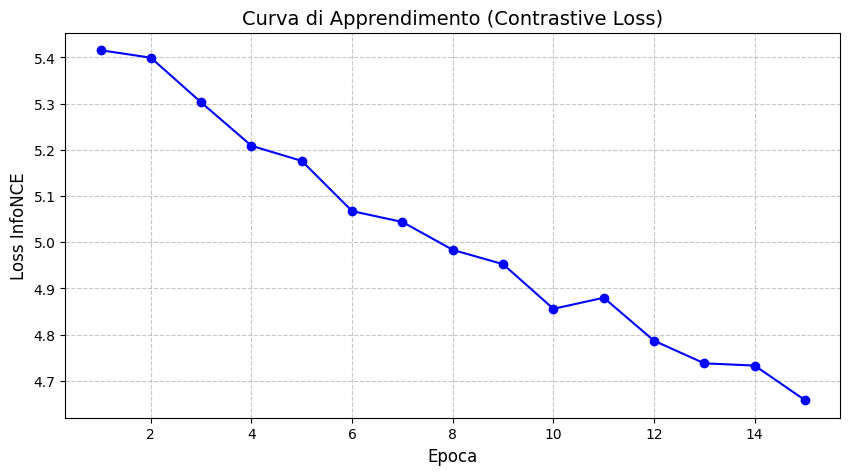

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from dataset import MoCoTextureDataset
from model import MoCo
import matplotlib.pyplot as plt
from tqdm import tqdm  # <-- La magica barra di caricamento!

print("--- FASE 1: Setup ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in uso: {device}")

BATCH_SIZE = 32
EPOCHS = 15
LR = 0.001

print("\nPreparazione del DataLoader...")
train_dataset = MoCoTextureDataset(data_dir='data/train/good', is_train=True)

# FIX FONDAMENTALE: num_workers=2 dice a Google Colab di usare 2 core in parallelo per calcolare i tuoi filtri custom!
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=True # Velocizza il trasferimento dati verso la GPU
)

model = MoCo(dim=128, K=1024).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f"\n🚀 INIZIO ADDESTRAMENTO MOCO ({EPOCHS} Epoche) 🚀")
losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    # Avvolgiamo il train_loader con tqdm per vedere a che punto è il batch!
    loop = tqdm(train_loader, desc=f"Epoca [{epoch+1}/{EPOCHS}]")

    for view_1, view_2 in loop:
        view_1, view_2 = view_1.to(device), view_2.to(device)

        optimizer.zero_grad()
        logits, labels = model(view_1, view_2)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        # Aggiorniamo la barra con la loss in tempo reale
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"-> Fine Epoca {epoch+1} | Loss Media: {avg_loss:.4f}\n")

print("\n✅ ADDESTRAMENTO CONCLUSO!")
torch.save(model.encoder_q.state_dict(), "moco_encoder_weights.pth")

plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), losses, marker='o', linestyle='-', color='b')
plt.title("Curva di Apprendimento (Contrastive Loss)", fontsize=14)
plt.xlabel("Epoca", fontsize=12)
plt.ylabel("Loss InfoNCE", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

--- FASE 1: Risveglio del Cervello ---
Pesi caricati con successo. Rete in modalità Eval.

--- FASE 2: Costruzione della Banca della Normalità ---
Banca completata! Forma della matrice: torch.Size([100, 128])

--- FASE 3: Calcolo dell'Anomaly Score ---
-> Score Immagine SANA:    0.0000
-> Score Immagine ANOMALA: 0.0907


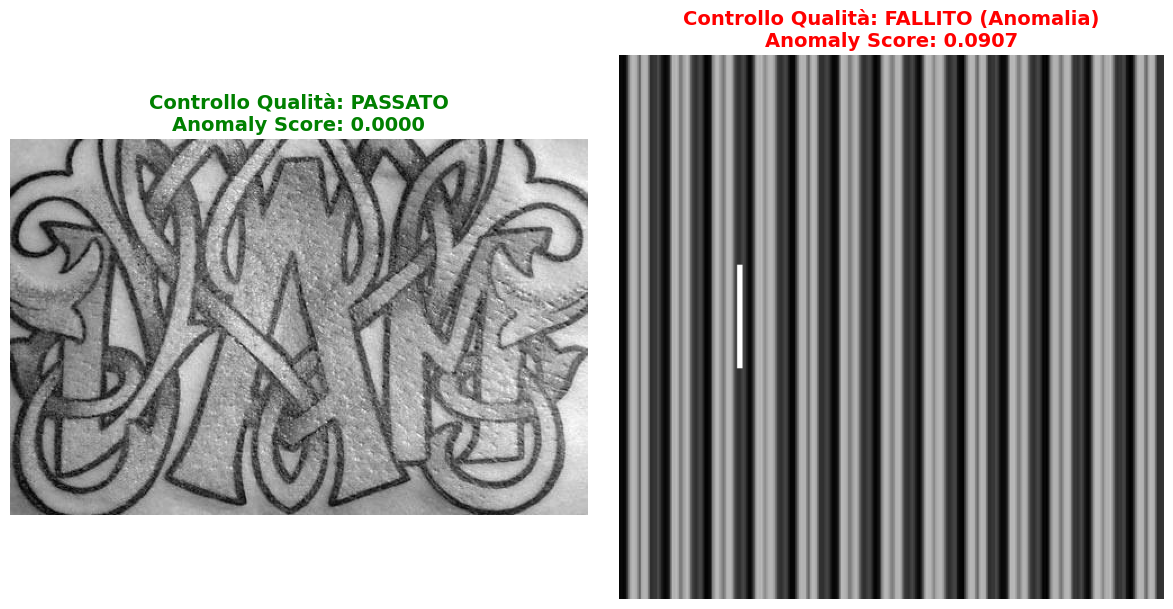

In [13]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np

# Importiamo solo la funzione per creare l'encoder, non ci serve più tutta l'impalcatura MoCo!
from model import create_encoder

print("--- FASE 1: Risveglio del Cervello ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Creiamo l'encoder vuoto e ci carichiamo dentro i "ricordi" (i pesi) che hai appena salvato
encoder = create_encoder(dim_projection=128).to(device)
encoder.load_state_dict(torch.load("moco_encoder_weights.pth", map_location=device))
encoder.eval() # Modalità inferenza: spegniamo l'apprendimento e i gradienti
print("Pesi caricati con successo. Rete in modalità Eval.")

# La trasformazione base per il test
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print("\n--- FASE 2: Costruzione della Banca della Normalità ---")
# Estraiamo le feature di 100 immagini sane per avere un riferimento statistico solido
train_dir = 'data/train/good'
train_paths = [os.path.join(train_dir, f) for f in os.listdir(train_dir)][:100]

normal_features = []
with torch.no_grad(): # Niente calcolo dei gradienti, risparmiamo memoria
    for path in train_paths:
        img = Image.open(path).convert('L')
        img_t = transform(img).unsqueeze(0).to(device)
        feat = encoder(img_t)
        feat = F.normalize(feat, dim=1) # Normalizziamo il vettore a lunghezza 1
        normal_features.append(feat)

# Impiliamo tutti i vettori sani in un'unica grande matrice [100, 128]
normal_bank = torch.cat(normal_features, dim=0)
print(f"Banca completata! Forma della matrice: {normal_bank.shape}")

print("\n--- FASE 3: Calcolo dell'Anomaly Score ---")
def get_anomaly_score(img_path):
    """
    Calcola quanto un'immagine è 'lontana' dalla normalità.
    """
    img = Image.open(img_path).convert('L')
    img_t = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feat = encoder(img_t)
        feat = F.normalize(feat, dim=1)

    # Calcoliamo la similarità tra questa immagine e TUTTE le 100 immagini sane
    similarities = torch.mm(feat, normal_bank.T) # Moltiplicazione tra matrici

    # Troviamo la texture sana più simile a questa
    max_sim = torch.max(similarities).item()

    # L'Anomaly Score è l'inverso della similarità: (1 - similarità)
    # Se è identica a una sana = 0. Se è diversissima = numero alto!
    anomaly_score = 1.0 - max_sim
    return img, anomaly_score

# Scegliamo un'immagine di training (dovrebbe avere score basso) e una di test (score alto)
img_sana, score_sano = get_anomaly_score(train_paths[0])
img_anomala, score_anomalo = get_anomaly_score('data/test/anomaly/anom_0.png')

print(f"-> Score Immagine SANA:    {score_sano:.4f}")
print(f"-> Score Immagine ANOMALA: {score_anomalo:.4f}")

# Visualizzazione del Trionfo
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title(f"Controllo Qualità: PASSATO\nAnomaly Score: {score_sano:.4f}", color='green', fontsize=14, fontweight='bold')
plt.imshow(img_sana, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Controllo Qualità: FALLITO (Anomalia)\nAnomaly Score: {score_anomalo:.4f}", color='red', fontsize=14, fontweight='bold')
plt.imshow(img_anomala, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

--- PREPARAZIONE DEL DATASET DI TEST ---
Totale immagini in test: 100 (50 Sane, 50 Anomale)

🤖 Valutazione in corso... (potrebbe richiedere un minuto per colpa dell'Entropia classica)


100%|██████████| 100/100 [00:40<00:00,  2.44it/s]


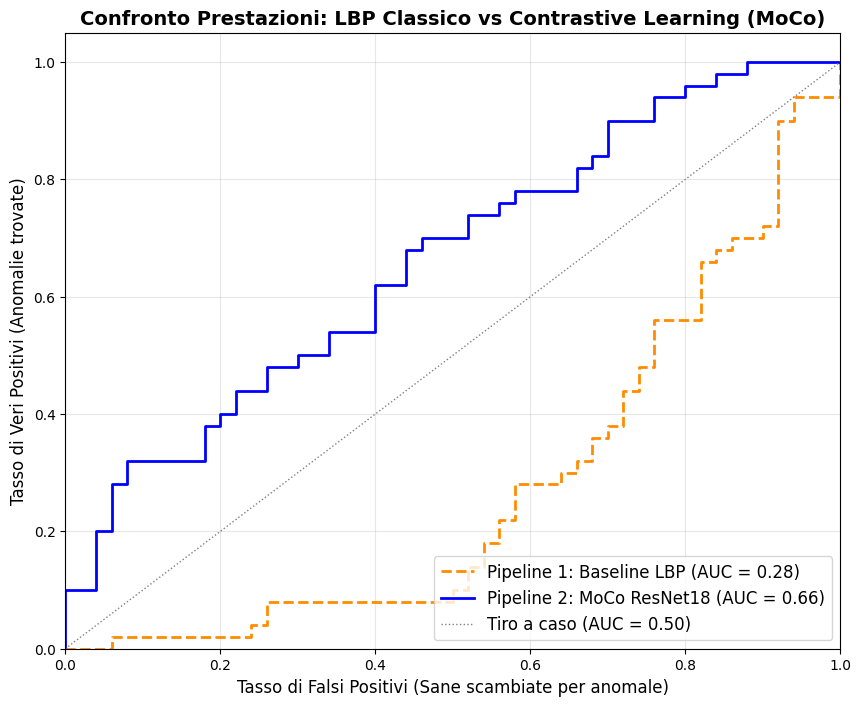

In [14]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_curve, auc
from skimage.feature import local_binary_pattern
from skimage.filters.rank import entropy
from skimage.morphology import disk
from tqdm import tqdm

print("--- PREPARAZIONE DEL DATASET DI TEST ---")
# Prendiamo 50 immagini sane (diverse dalle 100 usate per la Banca Normale!)
train_dir = 'data/train/good'
tutte_sane = sorted([os.path.join(train_dir, f) for f in os.listdir(train_dir)])
test_sane_paths = tutte_sane[-50:] # Prendiamo le ultime 50

# Prendiamo le 50 immagini anomale che hai generato all'inizio
anom_dir = 'data/test/anomaly'
test_anom_paths = sorted([os.path.join(anom_dir, f) for f in os.listdir(anom_dir)])[:50]

# Uniamo i percorsi e creiamo le etichette (0 = Sana, 1 = Anomalia)
test_paths = test_sane_paths + test_anom_paths
y_true = [0] * len(test_sane_paths) + [1] * len(test_anom_paths)

print(f"Totale immagini in test: {len(test_paths)} (50 Sane, 50 Anomale)")

# --- FUNZIONI DI SCORING ---

def baseline_score(img_path):
    """Calcola l'Anomaly Score usando la PIPELINE 1 (LBP + Entropia)"""
    img = cv2.imread(img_path, 0)
    radius = 3
    n_points = 8 * radius
    lbp_img = local_binary_pattern(img, n_points, radius, method='uniform')
    lbp_uint8 = cv2.normalize(lbp_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Calcoliamo l'entropia
    entropia_locale = entropy(lbp_uint8, disk(15))

    # L'Anomaly Score è il picco massimo di disordine (escludendo il 1% dei pixel estremi per i bordi)
    return np.percentile(entropia_locale, 99)

def moco_score(img_path):
    """Calcola l'Anomaly Score usando la PIPELINE 2 (MoCo + Cosine Distance)"""
    # Usiamo le variabili 'encoder', 'transform', 'device', e 'normal_bank' già caricate nella cella precedente
    img = Image.open(img_path).convert('L')
    img_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = encoder(img_t)
        feat = torch.nn.functional.normalize(feat, dim=1)

    similarities = torch.mm(feat, normal_bank.T)
    return 1.0 - torch.max(similarities).item()

# --- ESECUZIONE DELLA SFIDA ---
scores_baseline = []
scores_moco = []

print("\n🤖 Valutazione in corso... (potrebbe richiedere un minuto per colpa dell'Entropia classica)")
for path in tqdm(test_paths):
    scores_baseline.append(baseline_score(path))
    scores_moco.append(moco_score(path))

# --- CALCOLO DELLA CURVA ROC (ROC-AUC) ---
fpr_b, tpr_b, _ = roc_curve(y_true, scores_baseline)
roc_auc_baseline = auc(fpr_b, tpr_b)

fpr_m, tpr_m, _ = roc_curve(y_true, scores_moco)
roc_auc_moco = auc(fpr_m, tpr_m)

# --- IL GRAFICO FINALE ---
plt.figure(figsize=(10, 8))
plt.plot(fpr_b, tpr_b, color='darkorange', lw=2, linestyle='--', label=f'Pipeline 1: Baseline LBP (AUC = {roc_auc_baseline:.2f})')
plt.plot(fpr_m, tpr_m, color='blue', lw=2, label=f'Pipeline 2: MoCo ResNet18 (AUC = {roc_auc_moco:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':', label='Tiro a caso (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasso di Falsi Positivi (Sane scambiate per anomale)', fontsize=12)
plt.ylabel('Tasso di Veri Positivi (Anomalie trovate)', fontsize=12)
plt.title('Confronto Prestazioni: LBP Classico vs Contrastive Learning (MoCo)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()